In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ( RandomForestRegressor,GradientBoostingRegressor )
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt

In [4]:
from sklearn.metrics import ( mean_absolute_error, mean_squared_error, r2_score )

In [5]:
train = pd.read_csv("../dataset/cleaned/ready_to_train.csv")

train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SalePrice
0,-1.730865,0.454631,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,1.230517,0.614224,...,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276,208500.0
1,-1.728492,-1.143813,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.809621,1.242296,...,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276,181500.0
2,-1.726120,0.454631,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,1.157359,0.106224,...,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276,223500.0
3,-1.723747,0.682185,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.809621,-0.517230,...,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,NaN,-0.365276,140000.0
4,-1.721374,0.454631,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.453554,0.496460,...,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276,250000.0


In [6]:
missing = train.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

RoofStyle_Gable         319
MSZoning_RL             309
SaleCondition_Normal    262
Condition1_Norm         200
SaleType_WD             193
ExterCond_TA            178
BsmtFinType2_Unf        166
LandContour_Lvl         149
Electrical_SBrkr        125
PavedDrive_Y            120
BsmtCond_TA             112
Functional_Typ          100
CentralAir_Y             95
GarageQual_TA            68
GarageCond_TA            53
Heating_GasA             32
RoofMatl_CompShg         26
Condition2_Norm          15
Street_Pave               6
dtype: int64

In [7]:
numerical_columns = train.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    train[column] = train[column].fillna(train[column].median())

In [8]:
X = train.drop("SalePrice", axis=1)

y = train["SalePrice"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,-1.128206,-1.143813,0.052803,-0.347160,-0.798780,0.473866,-0.475091,-1.350194,-0.809621,1.112987,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1066,0.798404,0.454631,-0.585766,-0.503848,-0.073068,1.511894,0.720999,0.442586,-0.809621,-1.015994,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
638,-0.217100,-0.560012,-0.121352,-0.242237,-0.798780,1.511894,-2.036652,-1.689368,-0.809621,-1.015994,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
799,0.164901,0.186240,-0.527714,-0.681131,-0.798780,1.511894,-1.139585,-1.689368,1.327128,0.297878,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
380,-0.829249,0.186240,-1.108232,-1.293411,-0.798780,0.473866,-1.571506,-1.689368,-0.809621,-0.512612,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276


In [11]:
X_test.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
892,0.385559,-1.143813,0.052803,-0.343263,-0.073068,2.030907,-0.275742,0.878668,-0.809621,0.514933,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1105,0.890939,0.454631,1.678252,0.726001,1.378355,-0.564161,0.754224,0.491040,1.466535,1.366987,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
413,-0.750951,-0.560012,-0.759921,-0.191306,-0.798780,0.473866,-1.471832,-1.689368,-0.809621,-1.015994,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
522,-0.492330,0.186240,-1.108232,-1.293411,-0.073068,1.511894,-0.807338,-1.689368,-0.809621,-0.094667,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276
1036,0.727224,-1.143813,1.155787,0.904675,2.104067,-0.564161,1.186145,1.120936,0.836436,1.343896,...,-0.060409,-0.060409,-0.359481,-0.046438,0.329514,-0.053838,-0.095448,-0.125394,0.383663,-0.365276


In [12]:
y_train.head()

254     145000.0
1066    178000.0
638      85000.0
799     175000.0
380     127000.0
Name: SalePrice, dtype: float64

In [13]:
y_test.head()

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
Name: SalePrice, dtype: float64

In [14]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    ),

    "LightGBM": LGBMRegressor(
        random_state=42
    ),

    "CatBoost": CatBoostRegressor(
        verbose=0,
        random_state=42
    )
}
results = []

for model_name, model in models.items():

    model.fit( X_train, y_train )

    predictions = model.predict( X_test )

    print(model_name, "\n", predictions)

    mae = mean_absolute_error( y_test, predictions )

    mse = mean_squared_error(y_test,predictions)

    r2 = r2_score( y_test, predictions)

    results.append({ "Model": model_name, "MAE": mae, "MSE": mse, "R2 Score": r2})

Linear Regression 
 [157419.0454596  316604.8313203  109005.33926524 184576.62039245
 305558.17592596  71093.87635865 238685.324581   143457.33326713
  61705.65136701 139594.79532639 142397.93931769 111184.8496826
 122464.30617995 225296.73666354 180130.23333188 133308.64165112
 194062.25444271 135169.72519935 123623.51509578 219728.52257461
 172474.69915033 211582.45924074 172042.97560656 122747.64665839
 204443.30557587 152925.8205753  195073.55810333 110750.04859708
 177110.41232348 201013.06173326 133844.92372394 275123.45524825
 249326.10063805 113632.96573968 249352.78329858 144409.46912033
 136458.92839322 207966.47886612 317416.4557148  108437.70101171
 138466.9775855  229274.22840746 103592.49374301 312077.57820148
 133365.99976074 135289.80553309 105269.52436904 134041.02080542
 354862.96303746 126588.20682019 116226.10558771 210152.87784956
 112750.99133131 293597.73985722 161512.18571345 239963.28326611
 198051.22367695 175413.53370211 126732.70768119  87342.12789714
  6436

In [15]:
results

[{'Model': 'Linear Regression',
  'MAE': 15772.64982678635,
  'MSE': 535667665.63482225,
  'R2 Score': 0.8904397056731511},
 {'Model': 'Decision Tree',
  'MAE': 22591.56678082192,
  'MSE': 1049319981.4152397,
  'R2 Score': 0.785382218524142},
 {'Model': 'Random Forest',
  'MAE': 14800.120291095891,
  'MSE': 425196071.9312296,
  'R2 Score': 0.9130344992315378},
 {'Model': 'Gradient Boosting',
  'MAE': 14113.775134569776,
  'MSE': 392235499.18901104,
  'R2 Score': 0.9197759366609173},
 {'Model': 'XGBoost',
  'MAE': 15707.820713827055,
  'MSE': 466106912.282106,
  'R2 Score': 0.9046669907975746},
 {'Model': 'LightGBM',
  'MAE': 13997.545370467713,
  'MSE': 382230236.00884634,
  'R2 Score': 0.9218223166258857},
 {'Model': 'CatBoost',
  'MAE': 12765.161892304048,
  'MSE': 329486095.5778331,
  'R2 Score': 0.9326100940490201}]

In [16]:
results = pd.DataFrame(results)

results.sort_values( by="R2 Score", ascending=False )

,Model,MAE,MSE,R2 Score
6,CatBoost,12765.161892,3.294861e+08,0.932610
5,LightGBM,13997.545370,3.822302e+08,0.921822
3,Gradient Boosting,14113.775135,3.922355e+08,0.919776
2,Random Forest,14800.120291,4.251961e+08,0.913034
4,XGBoost,15707.820714,4.661069e+08,0.904667
0,Linear Regression,15772.649827,5.356677e+08,0.890440
1,Decision Tree,22591.566781,1.049320e+09,0.785382


In [19]:
best_model = CatBoostRegressor(
        verbose=0,
        random_state=42
    )

best_model.fit( X_train, y_train )

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [21]:
predictions = best_model.predict(X_test)

predictions

array([146255.34438204, 327401.20783072, 108798.54750265, 150934.5940142 ,
       310190.98190902,  75140.36475337, 239996.88173804, 142236.91037131,
        74832.42179372, 132106.51153554, 149529.74608015, 125003.34149347,
       121320.57335234, 201001.42493351, 177112.57615333, 133365.36910751,
       189192.63431231, 136764.0451492 , 116427.28047435, 220752.44416579,
       162859.21714443, 219565.77715315, 174147.74376162, 128049.24726618,
       202911.87186031, 163727.51643301, 198612.87484676, 107490.13695619,
       176483.5675211 , 191752.56211009, 121495.08991604, 269786.71605085,
       203349.74324835, 112487.41868127, 264743.26203854, 150508.93761269,
       130663.17129644, 203447.27276599, 326948.79733077, 107091.77011281,
       125320.09970198, 239540.06603181, 116763.53797929, 323150.47444861,
       124384.87028947, 125815.60676487, 109300.59924975, 125915.49295735,
       337495.14290269, 131244.92616691, 120474.57280066, 202485.15402713,
       109182.71926487, 3

In [22]:
best_model.feature_importances_

array([7.52354293e-01, 5.12235450e-01, 8.14536807e-01, 4.48649782e+00,
       2.49066456e+01, 2.18026476e+00, 2.16009437e+00, 1.96750974e+00,
       7.24233695e-01, 3.61613416e+00, 0.00000000e+00, 6.18677615e-01,
       5.01854485e+00, 4.29178616e+00, 1.73029861e+00, 0.00000000e+00,
       1.35311129e+01, 1.77534523e+00, 0.00000000e+00, 1.66369316e+00,
       7.19658832e-01, 3.75813396e-01, 0.00000000e+00, 1.47664486e+00,
       2.53512581e+00, 1.29838223e+00, 2.38379895e+00, 2.16535375e+00,
       1.01470318e+00, 1.04162035e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.11243995e-01,
       3.75140952e-01, 1.66838188e-01, 5.01685975e-03, 0.00000000e+00,
       3.74314654e-01, 0.00000000e+00, 3.78707005e-02, 2.53866444e-02,
       1.19164845e-01, 7.41501879e-02, 2.85370117e-02, 0.00000000e+00,
       2.10360036e-03, 1.83610177e-01, 4.41724833e-02, 0.00000000e+00,
       8.28430808e-02, 5.48951309e-04, 2.81619840e-02, 0.00000000e+00,
      

<Axes: >

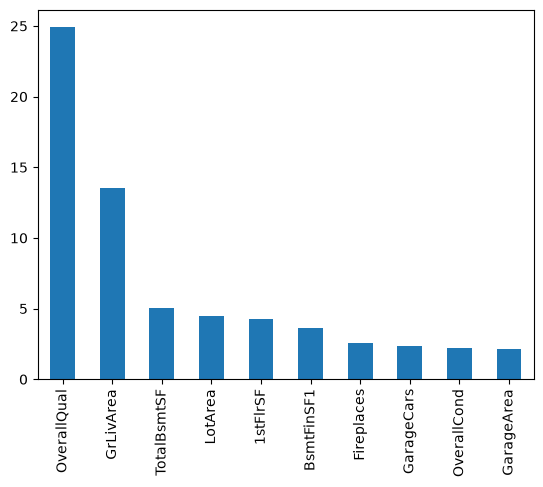

In [23]:
# importance Feature

importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(
    ascending=False
)

importance.head(10).plot(kind="bar")

# Model Training completed